In [ ]:
!pip install duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 83.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os
import glob
import numpy as np
import requests
from pathlib import Path
import time
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

## Functions

In [ ]:
def baixar_arquivo_parquet(url: str, pasta_destino: str, nome_arquivo: str, mes: str):
    try:
        output_folder = Path(pasta_destino)

        output_folder.mkdir(parents=True, exist_ok=True)

        nome_arquivo = nome_arquivo+".parquet"

        file_path = output_folder / nome_arquivo

        print(f"Iniciando o download de: {mes}")

        with requests.get(url, stream=True) as response:
            response.raise_for_status()

            with open(file_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)

            print(f"\nDownload concluído com sucesso!")
            return file_path
    except requests.exceptions.RequestException as e:
        print(f"\nERRO: Falha ao baixar o arquivo para o mês de {mes}.")
        print(f"Detalhes do erro: {e}")
        return None

In [ ]:
def load_files(archives_dir_path):
    df = pd.DataFrame()
    for file_path in glob.glob(os.path.join(archives_dir_path, "*.parquet")):
        if df.empty:
            df = pd.read_parquet(file_path)

            df_col = df.columns.values
            df_col = [item.lower() for item in df_col]
            df_col = [item.strip() for item in df_col]
            df_col = [item.replace(" ", "_") for item in df_col]


            rename_dict = dict(zip(df.columns.values, df_col))
            df.rename(columns=rename_dict, inplace=True)
        else:
            df_aux = pd.read_parquet(file_path)

            df_col = df_aux.columns.values
            df_col = [item.lower() for item in df_col]
            df_col = [item.strip() for item in df_col]
            df_col = [item.replace(" ", "_") for item in df_col]

            rename_dict = dict(zip(df_aux.columns.values, df_col))
            df_aux.rename(columns=rename_dict, inplace=True)

            df = pd.concat([df, df_aux])

    return df


In [ ]:
def benchmark_parquet_pandas(csv_path: str, amount: int):
  archive_path = Path(csv_path)
  times = []
  gc.collect()

  for i in range(amount):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = pd.read_parquet(archive_path)
    end = time.perf_counter()
    times.append(end - start)
    del df
    gc.collect()
  return times

In [ ]:
def benchmark_csv_pandas(csv_path: str, amount: int):
  archive_path = Path(csv_path)
  times = []
  gc.collect()

  for i in range(amount):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = pd.read_csv(archive_path, index_col=0)
    end = time.perf_counter()
    times.append(end - start)
    del df
    gc.collect()
  return times

In [ ]:
def benchmark_csv_duckdb(csv_path: str, amount: int):
  archive_path = Path(csv_path)
  times = []
  gc.collect()

  for i in range(amount):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = duckdb.query(f"SELECT * FROM read_csv_auto('{archive_path}');").df()
    end = time.perf_counter()
    times.append(end - start)
    del df
    gc.collect()
  return times

In [ ]:
def benchmark_parquet_duckdb(csv_path: str, amount: int):
  archive_path = Path(csv_path)
  times = []
  gc.collect()

  for i in range(amount):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = duckdb.query(f"SELECT * FROM '{archive_path}';").df()
    end = time.perf_counter()
    times.append(end - start)
    del df
    gc.collect()
  return times

In [ ]:
def print_metrics(array):
  print(f"Média: {round(np.mean(array), 2)}")
  print(f"Desvio Padrão: {round(np.std(array), 2)}")
  print("\n")

In [ ]:
def benchmark_duckdb_query(query):
  times = []
  gc.collect()

  for i in range(5):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = duckdb.query(query).df()
    end = time.perf_counter()
    times.append(end - start)
    if i < 4:
      del df
    gc.collect()
  return times, df

## Code

In [ ]:
archives_dir_path = Path("./parquet_files/")

### Download Automatizado
- Análise e padronização dos schemas

In [ ]:
for i in range(1, 13):
    if i < 10:
        url_download = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-0{i}.parquet"
    else:
        url_download = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-{i}.parquet"

    url2 = baixar_arquivo_parquet(url_download, archives_dir_path, f"saida_{i}", f"{i}")

Iniciando o download de: 1

Download concluído com sucesso!
Iniciando o download de: 2

Download concluído com sucesso!
Iniciando o download de: 3

Download concluído com sucesso!
Iniciando o download de: 4

Download concluído com sucesso!
Iniciando o download de: 5

Download concluído com sucesso!
Iniciando o download de: 6

Download concluído com sucesso!
Iniciando o download de: 7

Download concluído com sucesso!
Iniciando o download de: 8

Download concluído com sucesso!
Iniciando o download de: 9

Download concluído com sucesso!
Iniciando o download de: 10

Download concluído com sucesso!
Iniciando o download de: 11

Download concluído com sucesso!
Iniciando o download de: 12

Download concluído com sucesso!


### Limpeza dos Dados

In [ ]:
df = load_files(archives_dir_path)

KeyboardInterrupt: 

In [ ]:
df.head()

In [ ]:
# Tempo negativo e zero
drop_indexes = df[df["tpep_pickup_datetime"] >= df["tpep_dropoff_datetime"]].index
df.drop(drop_indexes, inplace=True)

In [ ]:
# Monetário negativo
monetary_cols = ['fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee']
for col in monetary_cols:
  df.drop(df[df[col] < 0].index, inplace=True)

In [ ]:
# Sem passageiros
df.drop(df[df["passenger_count"] == 0.0].index, inplace=True)

In [ ]:
# Dentro do periodo esperado
lower_bound = pd.to_datetime("01/01/2023")
upper_bound = pd.to_datetime("01/01/2024")

df.drop(df[(df["tpep_pickup_datetime"] <= lower_bound) | (df["tpep_pickup_datetime"] >= upper_bound)].index, inplace=True)
df.drop(df[(df["tpep_dropoff_datetime"] <= lower_bound) | (df["tpep_dropoff_datetime"] >= upper_bound)].index, inplace=True)

In [ ]:
len(df)

### Armazenamento

In [ ]:
df.to_csv("./taxi_csv.csv")

In [ ]:
df.to_parquet('./taxi_snappy.parquet', compression='snappy')

In [ ]:
df.to_parquet('./taxi_zstd.parquet', compression='zstd')

### Os tamanhos são:


In [ ]:
tamanho_csv = Path('./taxi_csv.csv').stat().st_size
tamanho_snappy = Path('./taxi_snappy.parquet').stat().st_size
tamanho_zstd = Path('./taxi_zstd.parquet').stat().st_size

print(f"Tamanho CSV: {tamanho_csv / 1e6:.2f} MB")
print(f"Tamanho Parquet Snappy: {tamanho_snappy / 1e6:.2f} MB")
print(f"Tamanho Parquet ZSTD: {tamanho_zstd / 1e6:.2f} MB")

Tamanho CSV: 3195.38 MB
Tamanho Parquet Snappy: 717.86 MB
Tamanho Parquet ZSTD: 523.04 MB


In [ ]:
df

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
7,2,2023-10-01 00:11:29,2023-10-01 00:32:55,2.0,14.93,1.0,N,208,239,1,37.30,1.0,0.5,14.77,6.94,1.0,65.76,2.5,1.75
9,1,2023-10-01 00:39:47,2023-10-01 00:48:48,1.0,1.30,1.0,N,125,231,1,10.00,3.5,0.5,2.00,0.00,1.0,17.00,2.5,0.00
11,2,2023-10-01 00:11:49,2023-10-01 00:33:31,1.0,2.52,1.0,N,232,158,1,19.10,1.0,0.5,4.82,0.00,1.0,28.92,2.5,0.00
12,2,2023-10-01 00:51:42,2023-10-01 01:02:51,2.0,4.04,1.0,N,161,42,1,17.70,1.0,0.5,4.54,0.00,1.0,27.24,2.5,0.00
13,2,2023-10-01 00:16:19,2023-10-01 00:27:27,1.0,1.70,1.0,N,148,170,1,11.40,1.0,0.5,3.28,0.00,1.0,19.68,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2846715,2,2023-09-30 23:08:00,2023-09-30 23:30:59,NaN,5.13,NaN,None,89,225,0,26.57,0.0,0.5,0.00,0.00,1.0,28.07,NaN,NaN
2846716,2,2023-09-30 23:28:48,2023-09-30 23:35:59,NaN,1.36,NaN,None,229,140,0,14.48,0.0,0.5,3.70,0.00,1.0,22.18,NaN,NaN
2846718,1,2023-09-30 23:42:18,2023-09-30 23:47:45,NaN,0.00,NaN,None,236,75,0,11.33,0.0,0.5,0.00,0.00,1.0,15.33,NaN,NaN
2846719,1,2023-09-30 23:03:35,2023-09-30 23:14:50,NaN,1.80,NaN,None,211,90,0,12.10,1.0,0.5,2.57,0.00,1.0,19.67,NaN,NaN


### Perguntas:
  - Houve mudanças de schema entre os meses?
    - Houve mudanças, na questão da padronização dos nomes das colunas
  - Qual estratégia para dados ausentes/inconsistentes?
    - Como pedido foram removidas as colunas que não se encaixavam no contexto correto
  - Como garantir reprodutibilidade do processo? Ou seja, outros analistas chegariam no
mesmo resultado que você?
    - Para garantir a reprodutibilidade foram as ações foram feitas por chamadas de função, garantindo que seja necessário apenas alterar na função, e não precisar desbrava o código ao longo das células


# Tarefa 2: Benchmark de Performance

### Tamanho dos Arquivos

In [ ]:
tamanho_csv = Path('./taxi_csv.csv').stat().st_size
tamanho_snappy = Path('./taxi_snappy.parquet').stat().st_size
tamanho_zstd = Path('./taxi_zstd.parquet').stat().st_size

print(f"Tamanho CSV: {tamanho_csv / 1e6:.2f} MB")
print(f"Tamanho Parquet Snappy: {tamanho_snappy / 1e6:.2f} MB")
print(f"Tamanho Parquet ZSTD: {tamanho_zstd / 1e6:.2f} MB")

Tamanho CSV: 3195.38 MB
Tamanho Parquet Snappy: 717.86 MB
Tamanho Parquet ZSTD: 523.04 MB


### Taxa de Compressão

In [ ]:
# Taxa de compressão relativa (quanto % do original ele ocupa)
taxa_snappy = (tamanho_snappy / tamanho_csv) * 100
taxa_zstd = (tamanho_zstd / tamanho_csv) * 100

# Redução percentual de tamanho (espaço economizado)
reducao_snappy = (1 - (tamanho_snappy / tamanho_csv)) * 100
reducao_zstd = (1 - (tamanho_zstd / tamanho_csv)) * 100

print("--- Análise de Compressão Relativa ao CSV ---")
print(f"Tamanho CSV (Base): {tamanho_csv / 1e6:.2f} MB")
print("-" * 40)
print(f"Tamanho Parquet Snappy: {tamanho_snappy / 1e6:.2f} MB")
print(f"  -> Ocupa {taxa_snappy:.2f}% do tamanho do CSV.")
print(f"  -> Redução de {reducao_snappy:.2f}% em relação ao CSV.")
print("-" * 40)
print(f"Tamanho Parquet ZSTD: {tamanho_zstd / 1e6:.2f} MB")
print(f"  -> Ocupa {taxa_zstd:.2f}% do tamanho do CSV.")
print(f"  -> Redução de {reducao_zstd:.2f}% em relação ao CSV.")
print("-" * 40)


--- Análise de Compressão Relativa ao CSV ---
Tamanho CSV (Base): 3195.38 MB
----------------------------------------
Tamanho Parquet Snappy: 717.86 MB
  -> Ocupa 22.47% do tamanho do CSV.
  -> Redução de 77.53% em relação ao CSV.
----------------------------------------
Tamanho Parquet ZSTD: 523.04 MB
  -> Ocupa 16.37% do tamanho do CSV.
  -> Redução de 83.63% em relação ao CSV.
----------------------------------------


### Visualização

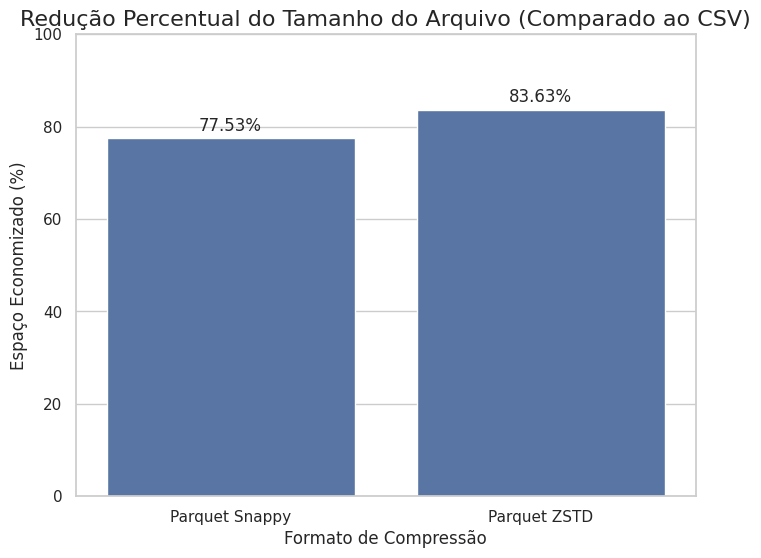

In [ ]:
dados_grafico = {
    'Formato': ['Parquet Snappy', 'Parquet ZSTD'],
    'Redução de Tamanho (%)': [reducao_snappy, reducao_zstd]
}
df_grafico = pd.DataFrame(dados_grafico)

# Criando o gráfico
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
barplot = sns.barplot(x='Formato', y='Redução de Tamanho (%)', data=df_grafico)

# Adicionando os valores no topo das barras
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title('Redução Percentual do Tamanho do Arquivo (Comparado ao CSV)', fontsize=16)
plt.ylabel('Espaço Economizado (%)', fontsize=12)
plt.xlabel('Formato de Compressão', fontsize=12)
plt.ylim(0, 100) # O eixo y vai de 0 a 100%
plt.show()

## Benchmark de carregamento:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/CiencDados/Downloads.zip" -d "./"

Archive:  /content/drive/MyDrive/CiencDados/Downloads.zip
  inflating: ./taxi_csv.csv          
  inflating: ./taxi_snappy.parquet   
  inflating: ./taxi_zstd.parquet     


In [ ]:
csv_times = benchmark_csv_pandas("./taxi_csv.csv", 5)

Começando a iteração: 0



/tmp/ipython-input-1538220278.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


Começando a iteração: 1



/tmp/ipython-input-1538220278.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


Começando a iteração: 2



/tmp/ipython-input-1538220278.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


Começando a iteração: 3



/tmp/ipython-input-1538220278.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


Começando a iteração: 4



/tmp/ipython-input-1538220278.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


In [ ]:
csv_times_duckdb = benchmark_csv_duckdb("./taxi_csv.csv", 5)

Começando a iteração: 0



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Começando a iteração: 1



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Começando a iteração: 2



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Começando a iteração: 3



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Começando a iteração: 4



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
parquet_times_duckdb = benchmark_parquet_duckdb("./taxi_zstd.parquet", 5)

Começando a iteração: 0

Começando a iteração: 1

Começando a iteração: 2

Começando a iteração: 3

Começando a iteração: 4



In [ ]:
parquet_times_pandas = benchmark_parquet_pandas("./taxi_zstd.parquet", 5)

Começando a iteração: 0

Começando a iteração: 1

Começando a iteração: 2

Começando a iteração: 3

Começando a iteração: 4



In [ ]:
print_metrics(csv_times)
print_metrics(csv_times_duckdb)
print_metrics(parquet_times_duckdb)
print_metrics(parquet_times_pandas)


Média: 32.36
Desvio Padrão: 0.68


Média: 8.11
Desvio Padrão: 0.18


Média: 3.37
Desvio Padrão: 0.04


Média: 2.0
Desvio Padrão: 0.1




## Benchmark de consultas

In [ ]:
path = "/content/taxi_zstd.parquet"
#df = duckdb.query(f"SELECT * FROM '{path}';").df()

In [ ]:
df

NameError: name 'df' is not defined

In [ ]:
#Padrões temporais: Agregação por mês/semana (COUNT viagens, SUM receita,
#AVG distância)
query1 =f"""
  SELECT DATE_TRUNC('month', tpep_pickup_datetime), COUNT(__index_level_0__), SUM(total_amount), AVG(trip_distance)
  FROM '{path}'
  GROUP BY DATE_TRUNC('month', tpep_pickup_datetime);
"""
times1, df1 = benchmark_duckdb_query(query1)
print_metrics(times1)
df1

Começando a iteração: 0

Começando a iteração: 1

Começando a iteração: 2

Começando a iteração: 3

Começando a iteração: 4

Média: 0.6
Desvio Padrão: 0.05




,"date_trunc('month', tpep_pickup_datetime)",count(__index_level_0__),sum(total_amount),avg(trip_distance)
0,2023-01-01,2251916,6.194406e+07,3.932098
1,2023-02-01,2127995,5.827865e+07,3.840102
2,2023-03-01,2547154,7.218996e+07,4.061913
3,2023-04-01,2439733,7.035039e+07,4.227489
4,2023-05-01,2655999,7.849717e+07,4.473457
5,2023-06-01,2456642,7.302272e+07,4.462314
6,2023-07-01,2122439,6.204594e+07,4.390367
7,2023-08-01,2056421,6.025007e+07,4.849973
8,2023-09-01,2074294,6.300997e+07,4.294013
9,2023-10-01,2664589,7.934059e+07,4.042449


In [ ]:
times11 = []
for i in range(5):
  start = time.time()
  df = pd.read_parquet(path)

  df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

  df = df.set_index('tpep_pickup_datetime')


  df_agregado = df.resample('MS').agg(
      numero_viagens=('total_amount', 'count'),

      receita_total=('total_amount', 'sum'),

      distancia_media=('trip_distance', 'mean')
  )

  df_agregado = df_agregado.round(2)

  df_agregado
  del df
  del df_agregado
  gc.collect()
  end = time.time()
  times11.append(end - start)
print(round(np.mean(times11), 2))
print(round(np.std(times11), 2))

14.35
1.07


In [ ]:
#Receita por zona: TOP 10 zonas de pickup por receita total média
query2 =f"""
  SELECT pulocationid, COUNT(*)
  FROM '{path}'
  GROUP BY pulocationid
  ORDER BY COUNT(*) DESC
  LIMIT 10;
"""
times2, df2 = benchmark_duckdb_query(query2)
print_metrics(times2)
df2

Começando a iteração: 0

Começando a iteração: 1

Começando a iteração: 2

Começando a iteração: 3

Começando a iteração: 4

Média: 0.07
Desvio Padrão: 0.03




,pulocationid,count_star()
0,132,1463129
1,237,1324846
2,161,1305623
3,236,1183922
4,162,1002597
5,138,968575
6,186,963768
7,230,939003
8,142,931098
9,170,839263


In [ ]:
times22 = []
for i in range(5):
    start = time.time()

    df = pd.read_parquet(path)

    top_10_zonas = df.groupby('pulocationid').size().nlargest(10)

    del df
    del top_10_zonas
    gc.collect()

    end = time.time()
    times22.append(end - start)

print(round(np.mean(times22), 2))
print(round(np.std(times22), 2))
df = pd.read_parquet(path)
top_10_zonas = df.groupby('pulocationid').size().nlargest(10)
print(top_10_zonas)
del df
del top_10_zonas
gc.collect()

2.41
0.05
pulocationid
132    1463129
237    1324846
161    1305623
236    1183922
162    1002597
138     968575
186     963768
230     939003
142     931098
170     839263
dtype: int64


0

In [ ]:
#Crescimento temporal: Taxa de crescimento mensal usando LAG/LEAD
query3 =f"""
  WITH VendasMensais AS (
    SELECT
        DATE_TRUNC('month', tpep_dropoff_datetime) AS mes,
        SUM(total_amount) AS total_mensal
    FROM '{path}'
    GROUP BY 1
)
SELECT
    mes,
    total_mensal,
    LAG(total_mensal, 1) OVER (ORDER BY mes) AS total_mes_anterior,
    (total_mensal - LAG(total_mensal, 1) OVER (ORDER BY mes)) / LAG(total_mensal, 1) OVER (ORDER BY mes) * 100 AS "crescimento_%"
FROM
    VendasMensais
ORDER BY
    mes;
"""
times3, df3 = benchmark_duckdb_query(query3)
print_metrics(times3)
df3

Começando a iteração: 0

Começando a iteração: 1

Começando a iteração: 2

Começando a iteração: 3

Começando a iteração: 4

Média: 0.42
Desvio Padrão: 0.06




,mes,total_mensal,total_mes_anterior,crescimento_%
0,2023-01-01,6.192141e+07,NaN,NaN
1,2023-02-01,5.827604e+07,6.192141e+07,-5.887089
2,2023-03-01,7.214888e+07,5.827604e+07,23.805391
3,2023-04-01,7.037885e+07,7.214888e+07,-2.453305
4,2023-05-01,7.849089e+07,7.037885e+07,11.526257
5,2023-06-01,7.301698e+07,7.849089e+07,-6.973951
6,2023-07-01,6.206933e+07,7.301698e+07,-14.993297
7,2023-08-01,6.023248e+07,6.206933e+07,-2.959352
8,2023-09-01,6.300417e+07,6.023248e+07,4.601658
9,2023-10-01,7.935494e+07,6.300417e+07,25.951897


In [ ]:
times33 = []
for i in range(5):
    start = time.time()

    df = pd.read_parquet(path)

    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    df = df.set_index('tpep_dropoff_datetime')

    df_mensal = df.resample('MS')['total_amount'].sum().to_frame()
    df_mensal.rename(columns={'total_amount': 'total_mensal'}, inplace=True)

    df_mensal['total_mes_anterior'] = df_mensal['total_mensal'].shift(1)

    df_mensal['crescimento_%'] = ((df_mensal['total_mensal'] - df_mensal['total_mes_anterior']) / df_mensal['total_mes_anterior']) * 100

    del df
    del df_mensal
    gc.collect()

    end = time.time()
    times33.append(end - start)

print(round(np.mean(times33), 2))
print(round(np.std(times33), 2))

df = pd.read_parquet(path)
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df = df.set_index('tpep_dropoff_datetime')
df_mensal = df.resample('MS')['total_amount'].sum().to_frame()
df_mensal.rename(columns={'total_amount': 'total_mensal'}, inplace=True)
df_mensal['total_mes_anterior'] = df_mensal['total_mensal'].shift(1)
df_mensal['crescimento_%'] = ((df_mensal['total_mensal'] - df_mensal['total_mes_anterior']) / df_mensal['total_mes_anterior']) * 100
print(df_mensal)

del df
del df_mensal
gc.collect()

14.21
0.12
                       total_mensal  total_mes_anterior  crescimento_%
tpep_dropoff_datetime                                                 
2023-01-01              61921408.85                 NaN            NaN
2023-02-01              58276040.55         61921408.85      -5.887089
2023-03-01              72148879.70         58276040.55      23.805391
2023-04-01              70378847.80         72148879.70      -2.453305
2023-05-01              78490894.32         70378847.80      11.526257
2023-06-01              73016977.87         78490894.32      -6.973951
2023-07-01              62069325.23         73016977.87     -14.993297
2023-08-01              60232475.39         62069325.23      -2.959352
2023-09-01              63004167.97         60232475.39       4.601658
2023-10-01              79354944.72         63004167.97      25.951897
2023-11-01              73022088.51         79354944.72      -7.980418
2023-12-01              73826975.00         73022088.51       1.10

0

In [ ]:
#Sazonalidade: Comparar receita mensal vs média anual usando window functions
query4 =f"""
  WITH ReceitaMensal AS (
    SELECT
        DATE_TRUNC('month', tpep_dropoff_datetime) AS mes,
        SUM(total_amount) AS receita_mensal
    FROM
        '{path}'
    GROUP BY
        mes
)
SELECT
    mes,
    receita_mensal,
    AVG(receita_mensal) OVER (PARTITION BY EXTRACT(year FROM mes)) AS media_mensal_do_ano,

    (receita_mensal - AVG(receita_mensal) OVER (PARTITION BY EXTRACT(year FROM mes))) AS diferenca_vs_media,

    ((receita_mensal / AVG(receita_mensal) OVER (PARTITION BY EXTRACT(year FROM mes))) - 1) * 100 AS percentual_vs_media
FROM
    ReceitaMensal
ORDER BY
    mes;
"""
times4, df4 = benchmark_duckdb_query(query4)
print_metrics(times4)
df4

Começando a iteração: 0

Começando a iteração: 1

Começando a iteração: 2

Começando a iteração: 3

Começando a iteração: 4

Média: 0.46
Desvio Padrão: 0.14




,mes,receita_mensal,media_mensal_do_ano,diferenca_vs_media,percentual_vs_media
0,2023-01-01,6.192141e+07,6.881192e+07,-6.890510e+06,-10.013541
1,2023-02-01,5.827604e+07,6.881192e+07,-1.053588e+07,-15.311124
2,2023-03-01,7.214888e+07,6.881192e+07,3.336961e+06,4.849394
3,2023-04-01,7.037885e+07,6.881192e+07,1.566929e+06,2.277119
4,2023-05-01,7.849089e+07,6.881192e+07,9.678975e+06,14.065842
5,2023-06-01,7.301698e+07,6.881192e+07,4.205059e+06,6.110946
6,2023-07-01,6.206933e+07,6.881192e+07,-6.742594e+06,-9.798584
7,2023-08-01,6.023248e+07,6.881192e+07,-8.579443e+06,-12.467961
8,2023-09-01,6.300417e+07,6.881192e+07,-5.807751e+06,-8.440036
9,2023-10-01,7.935494e+07,6.881192e+07,1.054303e+07,15.321511


In [ ]:
times44 = []
for i in range(5):
    start = time.time()

    df = pd.read_parquet(path)

    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    df = df.set_index('tpep_dropoff_datetime')

    df_mensal = df.resample('MS')['total_amount'].sum().to_frame()
    df_mensal.rename(columns={'total_amount': 'receita_mensal'}, inplace=True)

    df_mensal['media_mensal_do_ano'] = df_mensal.groupby(df_mensal.index.year)['receita_mensal'].transform('mean')

    df_mensal['diferenca_vs_media'] = df_mensal['receita_mensal'] - df_mensal['media_mensal_do_ano']
    df_mensal['percentual_vs_media'] = ((df_mensal['receita_mensal'] / df_mensal['media_mensal_do_ano']) - 1) * 100

    del df
    del df_mensal
    gc.collect()

    end = time.time()
    times44.append(end - start)

print(round(np.mean(times44), 2))
print(round(np.std(times44), 2))

df = pd.read_parquet(path)
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df = df.set_index('tpep_dropoff_datetime')
df_mensal = df.resample('MS')['total_amount'].sum().to_frame()
df_mensal.rename(columns={'total_amount': 'receita_mensal'}, inplace=True)
df_mensal['media_mensal_do_ano'] = df_mensal.groupby(df_mensal.index.year)['receita_mensal'].transform('mean')
df_mensal['diferenca_vs_media'] = df_mensal['receita_mensal'] - df_mensal['media_mensal_do_ano']
df_mensal['percentual_vs_media'] = ((df_mensal['receita_mensal'] / df_mensal['media_mensal_do_ano']) - 1) * 100
print(df_mensal)

del df
del df_mensal
gc.collect()

14.15
0.13
                       receita_mensal  media_mensal_do_ano  \
tpep_dropoff_datetime                                        
2023-01-01                61921408.85         6.881192e+07   
2023-02-01                58276040.55         6.881192e+07   
2023-03-01                72148879.70         6.881192e+07   
2023-04-01                70378847.80         6.881192e+07   
2023-05-01                78490894.32         6.881192e+07   
2023-06-01                73016977.87         6.881192e+07   
2023-07-01                62069325.23         6.881192e+07   
2023-08-01                60232475.39         6.881192e+07   
2023-09-01                63004167.97         6.881192e+07   
2023-10-01                79354944.72         6.881192e+07   
2023-11-01                73022088.51         6.881192e+07   
2023-12-01                73826975.00         6.881192e+07   

                       diferenca_vs_media  percentual_vs_media  
tpep_dropoff_datetime                                  

0

In [ ]:
#Padrões de fim de semana: Diferenças entre weekday/weekend usando window functions
query5 =f"""
WITH ViagensDiarias AS (
    SELECT
        DATE_TRUNC('day', tpep_pickup_datetime) AS dia,
        COUNT(*) AS numero_viagens,
        SUM(total_amount) AS receita_diaria
    FROM
        '{path}'
    GROUP BY
        dia
),
AnalisePorDiaDaSemana AS (
    SELECT
        dia,
        receita_diaria,
        DAYNAME(dia) as nome_dia_semana,
        AVG(receita_diaria) OVER (PARTITION BY DAYOFWEEK(dia)) AS media_receita_para_este_dia
    FROM
        ViagensDiarias
)
SELECT DISTINCT
    nome_dia_semana,
    CASE
        WHEN DAYOFWEEK(dia) IN (1, 7) THEN 'Fim de Semana' -- Domingo=1, Sábado=7 no DuckDB
        ELSE 'Dia de Semana'
    END AS tipo_de_dia,
    media_receita_para_este_dia
FROM
    AnalisePorDiaDaSemana
ORDER BY
    MIN(DAYOFWEEK(dia)) OVER (PARTITION BY nome_dia_semana);
"""
times5, df5 = benchmark_duckdb_query(query5)
print_metrics(times5)
df5

Começando a iteração: 0

Começando a iteração: 1

Começando a iteração: 2

Começando a iteração: 3

Começando a iteração: 4

Média: 0.26
Desvio Padrão: 0.08




,nome_dia_semana,tipo_de_dia,media_receita_para_este_dia
0,Sunday,Dia de Semana,2.012911e+06
1,Monday,Fim de Semana,2.053052e+06
2,Tuesday,Dia de Semana,2.301541e+06
3,Wednesday,Dia de Semana,2.429167e+06
4,Thursday,Dia de Semana,2.517729e+06
5,Friday,Dia de Semana,2.367889e+06
6,Saturday,Dia de Semana,2.158675e+06


In [ ]:
times55 = []
for i in range(5):
    start = time.time()

    df = pd.read_parquet(path)

    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df = df.set_index('tpep_pickup_datetime')

    df_diario = df.resample('D').agg(
        receita_diaria=('total_amount', 'sum')
    )

    df_diario['nome_dia_semana'] = df_diario.index.day_name()

    df_diario['media_receita_para_este_dia'] = df_diario.groupby('nome_dia_semana')['receita_diaria'].transform('mean')

    df_resumo = df_diario.groupby('nome_dia_semana')['media_receita_para_este_dia'].first().to_frame()

    df_resumo['tipo_de_dia'] = df_resumo.index.map(lambda x: 'Fim de Semana' if x in ['Saturday', 'Sunday'] else 'Dia de Semana')

    dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df_resumo = df_resumo.reindex(dias_ordenados)

    del df
    del df_diario
    del df_resumo
    gc.collect()

    end = time.time()
    times55.append(end - start)

print(round(np.mean(times55), 2))
print(round(np.std(times55), 2))

df = pd.read_parquet(path)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df = df.set_index('tpep_pickup_datetime')
df_diario = df.resample('D').agg(
    receita_diaria=('total_amount', 'sum')
)
df_diario['nome_dia_semana'] = df_diario.index.day_name()
df_diario['media_receita_para_este_dia'] = df_diario.groupby('nome_dia_semana')['receita_diaria'].transform('mean')
df_resumo = df_diario.groupby('nome_dia_semana')['media_receita_para_este_dia'].first().to_frame()
df_resumo['tipo_de_dia'] = df_resumo.index.map(lambda x: 'Fim de Semana' if x in ['Saturday', 'Sunday'] else 'Dia de Semana')
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_resumo = df_resumo.reindex(dias_ordenados)
print(df_resumo)

del df
del df_diario
del df_resumo
gc.collect()

13.08
0.01
                 media_receita_para_este_dia    tipo_de_dia
nome_dia_semana                                            
Monday                          2.053052e+06  Dia de Semana
Tuesday                         2.301541e+06  Dia de Semana
Wednesday                       2.429167e+06  Dia de Semana
Thursday                        2.517729e+06  Dia de Semana
Friday                          2.367889e+06  Dia de Semana
Saturday                        2.158675e+06  Fim de Semana
Sunday                          2.012911e+06  Fim de Semana


0

In [ ]:
all_benchmark_data = [
    # Query 1 - Agregação Temporal
    {'nome_da_query': '1. Agregação Temporal', 'media_tempo_execucao': np.mean(times1), 'dp_tempo_execucao': np.std(times1), 'ferramenta': 'duckdb'},
    {'nome_da_query': '1. Agregação Temporal', 'media_tempo_execucao': np.mean(times11), 'dp_tempo_execucao': np.std(times11), 'ferramenta': 'pandas'},

    # Query 2 - TOP 10 Zonas
    {'nome_da_query': '2. TOP 10 Zonas', 'media_tempo_execucao': np.mean(times2), 'dp_tempo_execucao': np.std(times2), 'ferramenta': 'duckdb'},
    {'nome_da_query': '2. TOP 10 Zonas', 'media_tempo_execucao': np.mean(times22), 'dp_tempo_execucao': np.std(times22), 'ferramenta': 'pandas'},

    # Query 3 - Crescimento Mensal (LAG)
    {'nome_da_query': '3. Crescimento Mensal (LAG)', 'media_tempo_execucao': np.mean(times3), 'dp_tempo_execucao': np.std(times3), 'ferramenta': 'duckdb'},
    {'nome_da_query': '3. Crescimento Mensal (LAG)', 'media_tempo_execucao': np.mean(times33), 'dp_tempo_execucao': np.std(times33), 'ferramenta': 'pandas'},

    # Query 4 - Sazonalidade (Window)
    {'nome_da_query': '4. Sazonalidade (Window)', 'media_tempo_execucao': np.mean(times4), 'dp_tempo_execucao': np.std(times4), 'ferramenta': 'duckdb'},
    {'nome_da_query': '4. Sazonalidade (Window)', 'media_tempo_execucao': np.mean(times44), 'dp_tempo_execucao': np.std(times44), 'ferramenta': 'pandas'},

    # Query 5 - Padrões Fim de Semana
    {'nome_da_query': '5. Padrões Fim de Semana', 'media_tempo_execucao': np.mean(times5), 'dp_tempo_execucao': np.std(times5), 'ferramenta': 'duckdb'},
    {'nome_da_query': '5. Padrões Fim de Semana', 'media_tempo_execucao': np.mean(times55), 'dp_tempo_execucao': np.std(times55), 'ferramenta': 'pandas'}
]

# Criar o DataFrame final
df_benchmark_final = pd.DataFrame(all_benchmark_data)

# Arredondar os valores para 4 casas decimais para melhor visualização
df_benchmark_final['media_tempo_execucao'] = df_benchmark_final['media_tempo_execucao'].round(4)

# Exibir o DataFrame final
print("--- DataFrame Consolidado do Benchmark de Consultas (Dinâmico) ---")
display(df_benchmark_final)

--- DataFrame Consolidado do Benchmark de Consultas (Dinâmico) ---


,nome_da_query,media_tempo_execucao,dp_tempo_execucao,ferramenta
0,1. Agregação Temporal,0.6017,0.045421,duckdb
1,1. Agregação Temporal,14.3461,1.068188,pandas
2,2. TOP 10 Zonas,0.0661,0.034434,duckdb
3,2. TOP 10 Zonas,2.4063,0.052469,pandas
4,3. Crescimento Mensal (LAG),0.4175,0.056997,duckdb
5,3. Crescimento Mensal (LAG),14.2094,0.121202,pandas
6,4. Sazonalidade (Window),0.4561,0.135205,duckdb
7,4. Sazonalidade (Window),14.1545,0.126930,pandas
8,5. Padrões Fim de Semana,0.2607,0.081521,duckdb
9,5. Padrões Fim de Semana,13.0820,0.014953,pandas


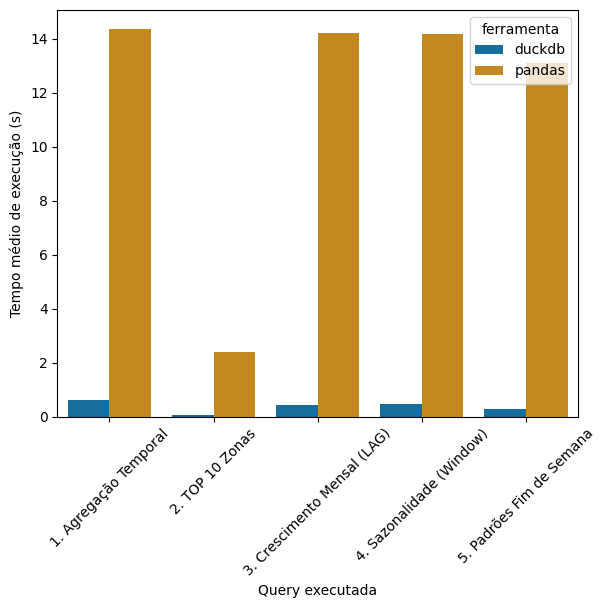

In [ ]:
sns.barplot(
    data=df_benchmark_final,
    x="nome_da_query",
    y="media_tempo_execucao",
    hue="ferramenta",
    palette="colorblind"
)
plt.tight_layout(),
plt.ylabel("Tempo médio de execução (s)")
plt.xlabel("Query executada")
plt.xticks(rotation=45)

plt.savefig("/content/drive/MyDrive/CiencDados/benchmark_duckdb_vs_pandas")
plt.show()

In [ ]:
df_comparacao = df_benchmark_final.pivot(
    index='nome_da_query',
    columns='ferramenta',
    values='media_tempo_execucao'
)

df_comparacao = df_comparacao.rename(columns={'duckdb': 'tempo_duckdb', 'pandas': 'tempo_pandas'})

df_comparacao['fator_aceleracao_x'] = df_comparacao['tempo_pandas'] / df_comparacao['tempo_duckdb']

df_comparacao = df_comparacao.round(2)

print("--- DataFrame Comparativo: DuckDB vs Pandas ---")
display(df_comparacao)

--- DataFrame Comparativo: DuckDB vs Pandas ---


ferramenta,tempo_duckdb,tempo_pandas,fator_aceleracao_x
nome_da_query,,,
1. Agregação Temporal,0.60,14.35,23.84
2. TOP 10 Zonas,0.07,2.41,36.40
3. Crescimento Mensal (LAG),0.42,14.21,34.03
4. Sazonalidade (Window),0.46,14.15,31.03
5. Padrões Fim de Semana,0.26,13.08,50.18


/tmp/ipython-input-4142462625.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


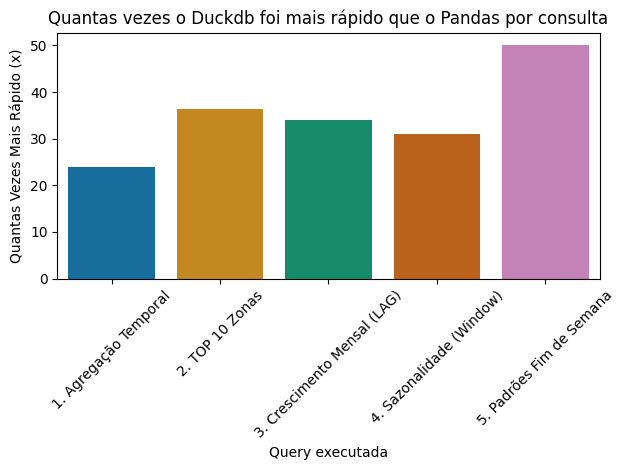

In [ ]:
barplot = sns.barplot(
    x=df_comparacao.index,
    y=df_comparacao['fator_aceleracao_x'],
    palette="colorblind"
)

plt.title('Quantas vezes o Duckdb foi mais rápido que o Pandas por consulta')
plt.xlabel('Query executada')
plt.ylabel('Quantas Vezes Mais Rápido (x)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/CiencDados/duckdb_pandas_speed_comparation")

plt.show()